In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from pp5.stats.mht import mht_bh

In [2]:
BASE_PATH = Path("../out/pnas-2026/").resolve()

RESULTS_DIR = BASE_PATH / "results"
assert RESULTS_DIR.is_dir(), f"Results directory {RESULTS_DIR} does not exist"

OUT_DIR = BASE_PATH / "figs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.absolute()

PosixPath('/Users/avivr/dev/technion/phd/pp5/out/pnas-2026/figs')

## Load analyis results

In [3]:
# Data

LABELLED_TAGS = {
    ### torustest, w2torus metric (no permutation test)
    "w2torus(2-random); none": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=2_randproj=True-cr=none-noself",
    "w2torus(2-random); aa_ss": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=2_randproj=True-cr=aa_ss-noself",
    #
    "w2torus(4-fixed); none": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=4_randproj=False-cr=none-noself",
    "w2torus(4-fixed); aa_ss": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=4_randproj=False-cr=aa_ss-noself",
    #
    ### Permutation test with w2torus metric
    #
    "w2torus-perm(2-random); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=2_randproj=True-cr=none-noself",
    "w2torus-perm(2-random); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=2_randproj=True-cr=aa_ss-noself",
    #
    "w2torus-perm(4-fixed); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=4_randproj=False-cr=none-noself",
    "w2torus-perm(4-fixed); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=4_randproj=False-cr=aa_ss-noself",
    ### Permutation test with KDE-L1 metric
    # #
    "kde-l1(bw=10.0); none": "pointwise_cdist-manual-t_1-bs_1-k_5000-nmax_0-kde_g_10.0-cr_none-noself",
    "kde-l1(bw=10.0); aa_ss": "pointwise_cdist-manual-t_1-bs_1-k_5000-nmax_0-kde_g_10.0-cr_aa_ss-noself",
    # #
    "kde-l1(bw=CV); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-kde_g_bw=cv-cr=none-noself",
    "kde-l1(bw=CV); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-kde_g_bw=cv-cr=aa_ss-noself",
}

PVALS_FILENAME = "pvals/cc-pvals.csv"

LABELLED_CSV_PATHS = {
    label: Path(RESULTS_DIR) / tag / PVALS_FILENAME
    for label, tag in LABELLED_TAGS.items()
}

In [4]:
for _, _csv_path in LABELLED_CSV_PATHS.items():
    assert _csv_path.is_file(), str(_csv_path)

In [5]:
_csv_path = next(iter(LABELLED_CSV_PATHS.values()))
_df = pd.read_csv(_csv_path)
_df.head()

,condition_group,subgroup1,subgroup2,n1,n2,phi1_mean,psi1_mean,phi2_mean,psi2_mean,d12,pval,ddist,significant
0,HELIX,L-CTC,L-CTG,528,2812,-66.176835,-37.717240,-65.223519,-39.349970,1.890666,0.000,0.452742,True
1,HELIX,L-CTC,L-TTG,528,599,-66.176835,-37.717240,-65.148195,-39.742460,2.271478,0.000,0.369836,True
2,HELIX,P-CCC,P-CCT,92,151,-59.370040,-35.431395,-58.398541,-36.500818,1.444810,0.026,0.193612,False
3,HELIX,G-GGA,G-GGT,153,462,-63.320628,-39.383827,-60.929911,-42.138466,3.647405,0.031,0.218664,False
4,HELIX,Q-CAA,Q-CAG,828,1629,-65.262840,-38.494280,-65.033755,-38.954806,0.514357,0.031,0.207236,False


In [6]:
def _get_stat_test_type(k: str) -> str:
    return k.split(";")[0].strip()


def _get_randomization_type(k: str) -> str:
    return k.split(";")[1].strip()


### Load all pval csvs into single df

In [7]:
pval_dfs = []

for run_label, csv_path in LABELLED_CSV_PATHS.items():
    df = pd.read_csv(csv_path).copy()

    stat_test_name = _get_stat_test_type(run_label)
    randomization_type = _get_randomization_type(run_label)

    df["stat_test"] = stat_test_name
    df["codon_randomization"] = randomization_type
    pval_dfs.append(df)

In [8]:
df_all_pvals = pd.concat(pval_dfs, axis=0)
df_all_pvals.to_csv(OUT_DIR / "pvals.csv", index=False)
df_all_pvals

,condition_group,subgroup1,subgroup2,n1,n2,phi1_mean,psi1_mean,phi2_mean,psi2_mean,d12,pval,ddist,significant,stat_test,codon_randomization
0,HELIX,L-CTC,L-CTG,528,2812,-66.176835,-37.717240,-65.223519,-39.349970,1.890666,0.000000,0.452742,True,w2torus(2-random),none
1,HELIX,L-CTC,L-TTG,528,599,-66.176835,-37.717240,-65.148195,-39.742460,2.271478,0.000000,0.369836,True,w2torus(2-random),none
2,HELIX,P-CCC,P-CCT,92,151,-59.370040,-35.431395,-58.398541,-36.500818,1.444810,0.026000,0.193612,False,w2torus(2-random),none
3,HELIX,G-GGA,G-GGT,153,462,-63.320628,-39.383827,-60.929911,-42.138466,3.647405,0.031000,0.218664,False,w2torus(2-random),none
4,HELIX,Q-CAA,Q-CAG,828,1629,-65.262840,-38.494280,-65.033755,-38.954806,0.514357,0.031000,0.207236,False,w2torus(2-random),none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,TURN,S-TCA,S-TCC,156,224,-73.889062,-9.825850,-72.864800,-6.070989,3.892056,0.980392,0.411151,False,kde-l1(bw=CV),aa_ss
344,TURN,R-AGA,R-CGA,37,88,-70.794883,8.325403,-66.554292,1.724830,7.845392,0.990099,0.468606,False,kde-l1(bw=CV),aa_ss
345,TURN,G-GGC,G-GGT,1606,1319,80.869529,1.705079,79.732616,2.330890,1.297771,0.990099,0.110475,False,kde-l1(bw=CV),aa_ss
346,TURN,S-AGC,S-AGT,388,224,-73.538577,-6.302294,-72.289923,-5.694079,1.388907,1.000000,0.113379,False,kde-l1(bw=CV),aa_ss


In [9]:
stat_test_names = sorted(df_all_pvals["stat_test"].unique())
randomization_names = sorted(df_all_pvals["codon_randomization"].unique())

stat_test_names, randomization_names

(['kde-l1(bw=10.0)',
  'kde-l1(bw=CV)',
  'w2torus(2-random)',
  'w2torus(4-fixed)',
  'w2torus-perm(2-random)',
  'w2torus-perm(4-fixed)'],
 ['aa_ss', 'none'])


## Compute number of rejections across all AAs in each SS

In [10]:
import re

FDR = 0.05

# Human-readable display names for each statistical test type, randomization strategy,
# and secondary-structure class used in plot labels and table output.
test_type_display = {
    "kde-l1": "Permutation test (KDE-L1)",
    "w2torus": "Torus test (Projected Wasserstein)",
    "w2torus-perm": "Permutation test (Projected Wasserstein)",
}
randomization_display = {
    "aa_ss": "Randomized control",
    "none": "Real data",
}
ss_display = {
    "HELIX": "HELIX",
    "SHEET": "SHEET",
    "TURN": "TURN",
    "OTHER": "OTHER",
}


In [11]:
def _parse_stat_test_name(stat_test_name: str) -> tuple[str, str]:
    """Split a label like 'w2torus(2-random)' into ('w2torus', '2-random').

    Returns (test_type, test_params); test_params is an empty string when no
    parenthesized parameters are present.
    """
    match = re.fullmatch(
        r"\s*(?P<test_type>[^()]+?)(?:\((?P<test_params>.*)\))?\s*", stat_test_name
    )
    if not match:
        raise ValueError(f"Could not parse stat test label: {stat_test_name}")

    test_type = match.group("test_type").strip()
    test_params = (match.group("test_params") or "").strip()
    return test_type, test_params


In [12]:
# ── BH multiple-testing correction per (stat_test * randomization * SS) group ─
# For each combination we pool all codon-pair p-values within that SS class,
# apply the Benjamini–Hochberg procedure at level FDR, and record:
# - bh_pvalue_threshold: the BH threshold p* (reject hypotheses with p ≤ p*)
# - n_rejected: number of codon pairs whose p-value ≤ p*
# - n_hypotheses: total number of codon pairs tested in the group (should be 87 for all groups)

rejections_df_entries = []

for (stat_test_name, randomization_type, ss), df_group in df_all_pvals.groupby(
    by=["stat_test", "codon_randomization", "condition_group"], sort=False
):
    pvals = df_group["pval"].to_numpy()
    m = len(pvals)  # total number of hypotheses (codon pairs) in this SS class
    if m < 1:
        raise RuntimeError("Empty p-value group encountered")

    # BH threshold: reject null hypotheses whose p-value is at or below this value.
    p_thresh = mht_bh(q=FDR, pvals=pvals)
    pv_lt_thresh = pvals <= p_thresh  # boolean mask of rejected hypotheses
    n_rejected = int(np.sum(pv_lt_thresh))  # number of rejections out of m

    df_group_rejected = df_group[pv_lt_thresh]
    assert len(df_group_rejected) == n_rejected

    # Collect the rejected codon-pair labels for inspection / downstream use.
    rejected_pairs = [
        f"{c1}:{c2}"
        for c1, c2 in zip(
            df_group_rejected["subgroup1"], df_group_rejected["subgroup2"]
        )
    ]
    rejected_pairs_str = str.join("; ", rejected_pairs)

    test_type, test_params = _parse_stat_test_name(stat_test_name)
    rejections_df_entries.append(
        {
            "stat_test": stat_test_name,
            "test_type": test_type,
            "test_params": test_params,
            "test_family": test_type_display.get(test_type, test_type),
            "codon_randomization": randomization_type,
            "randomization_label": randomization_display.get(
                randomization_type, randomization_type
            ),
            "SS": ss,
            "n_hypotheses": m,  # total codon-pair tests in this SS class
            "FDR": FDR,
            "bh_pvalue_threshold": p_thresh,
            "n_rejected": n_rejected,
            "rejected_pairs": rejected_pairs_str,
        }
    )

df_rejections = pd.DataFrame(rejections_df_entries)
df_rejections = df_rejections.sort_values(
    by=["stat_test", "codon_randomization", "SS"], kind="stable"
).reset_index(drop=True)
df_rejections.head()


,stat_test,test_type,test_params,test_family,codon_randomization,randomization_label,SS,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,HELIX,87,0.05,0.000000,0,
1,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,OTHER,87,0.05,0.000000,0,
2,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,SHEET,87,0.05,0.000000,0,
3,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,TURN,87,0.05,0.000000,0,
4,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),none,Real data,HELIX,87,0.05,0.001149,2,L-CTC:L-TTG; L-CTC:L-CTG


In [13]:
df_rejections.to_csv(OUT_DIR / "rejections.csv", index=False)



## Plot pval CDFs per SS type

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pp5.plot import PP5_MPL_STYLE

ss_colors = {
    "HELIX": "#e41a1c",
    "SHEET": "#377eb8",
    "TURN": "#4daf4a",
    "OTHER": "#984ea3",
}


In [15]:
# ── Build an ordered table of unique stat-test configurations ─────────────────
# Iterate over LABELLED_TAGS to collect one entry per unique stat-test name
# (ignoring the randomization suffix), preserving the order of first appearance.
plot_rows = []
seen_stat_tests = set()
for run_label in LABELLED_TAGS:
    stat_test_name = _get_stat_test_type(run_label)
    if stat_test_name in seen_stat_tests:
        continue
    seen_stat_tests.add(stat_test_name)

    test_type, test_params = _parse_stat_test_name(stat_test_name)
    plot_rows.append(
        {
            "stat_test": stat_test_name,  # full label, e.g. "w2torus(2-random)"
            "test_type": test_type,  # base method, e.g. "w2torus"
            "test_params": test_params,  # parameter string, e.g. "2-random"
            "test_family": test_type_display.get(test_type, test_type),  # display name
        }
    )

df_plot_rows = pd.DataFrame(plot_rows)

# Assign a rank to each test_type based on the preferred display order defined in
# test_type_display; unknown types are placed after all known types.
test_type_rank = {name: idx for idx, name in enumerate(test_type_display)}
df_plot_rows["type_rank"] = df_plot_rows["test_type"].map(
    lambda name: test_type_rank.get(name, len(test_type_rank))
)
# Preserve within-family appearance order so rows within a family stay consistent.
df_plot_rows["appearance_rank"] = np.arange(len(df_plot_rows))
df_plot_rows = df_plot_rows.sort_values(
    by=["type_rank", "appearance_rank"], kind="stable"
).reset_index(drop=True)

# ── Ordered axis lists for the plot grid ──────────────────────────────────────
# stat_test_order  : row order in the figure (one row per stat-test configuration)
# randomization_order: column order (preferred order from display dict, then any extras)
# ss_order         : line order within each panel (HELIX, SHEET, TURN, OTHER first)
stat_test_order = df_plot_rows["stat_test"].tolist()
randomization_order = [
    name
    for name in randomization_display
    if name in set(df_all_pvals["codon_randomization"])
]
randomization_order += [
    name
    for name in df_all_pvals["codon_randomization"].unique()
    if name not in set(randomization_order)
]
ss_order = [ss for ss in ss_display if ss in set(df_all_pvals["condition_group"])]
ss_order += [
    ss for ss in df_all_pvals["condition_group"].unique() if ss not in set(ss_order)
]


In [16]:
# Total number of rejected hypotheses per (stat_test, codon_randomization) panel
panel_rejections = df_rejections.groupby(
    by=["stat_test", "codon_randomization"], sort=False
)["n_rejected"].sum()

# Row indices grouped by test family, used later to draw dividers between families
family_row_groups = [
    group.index.to_list()
    for _, group in df_plot_rows.groupby("test_family", sort=False)
]


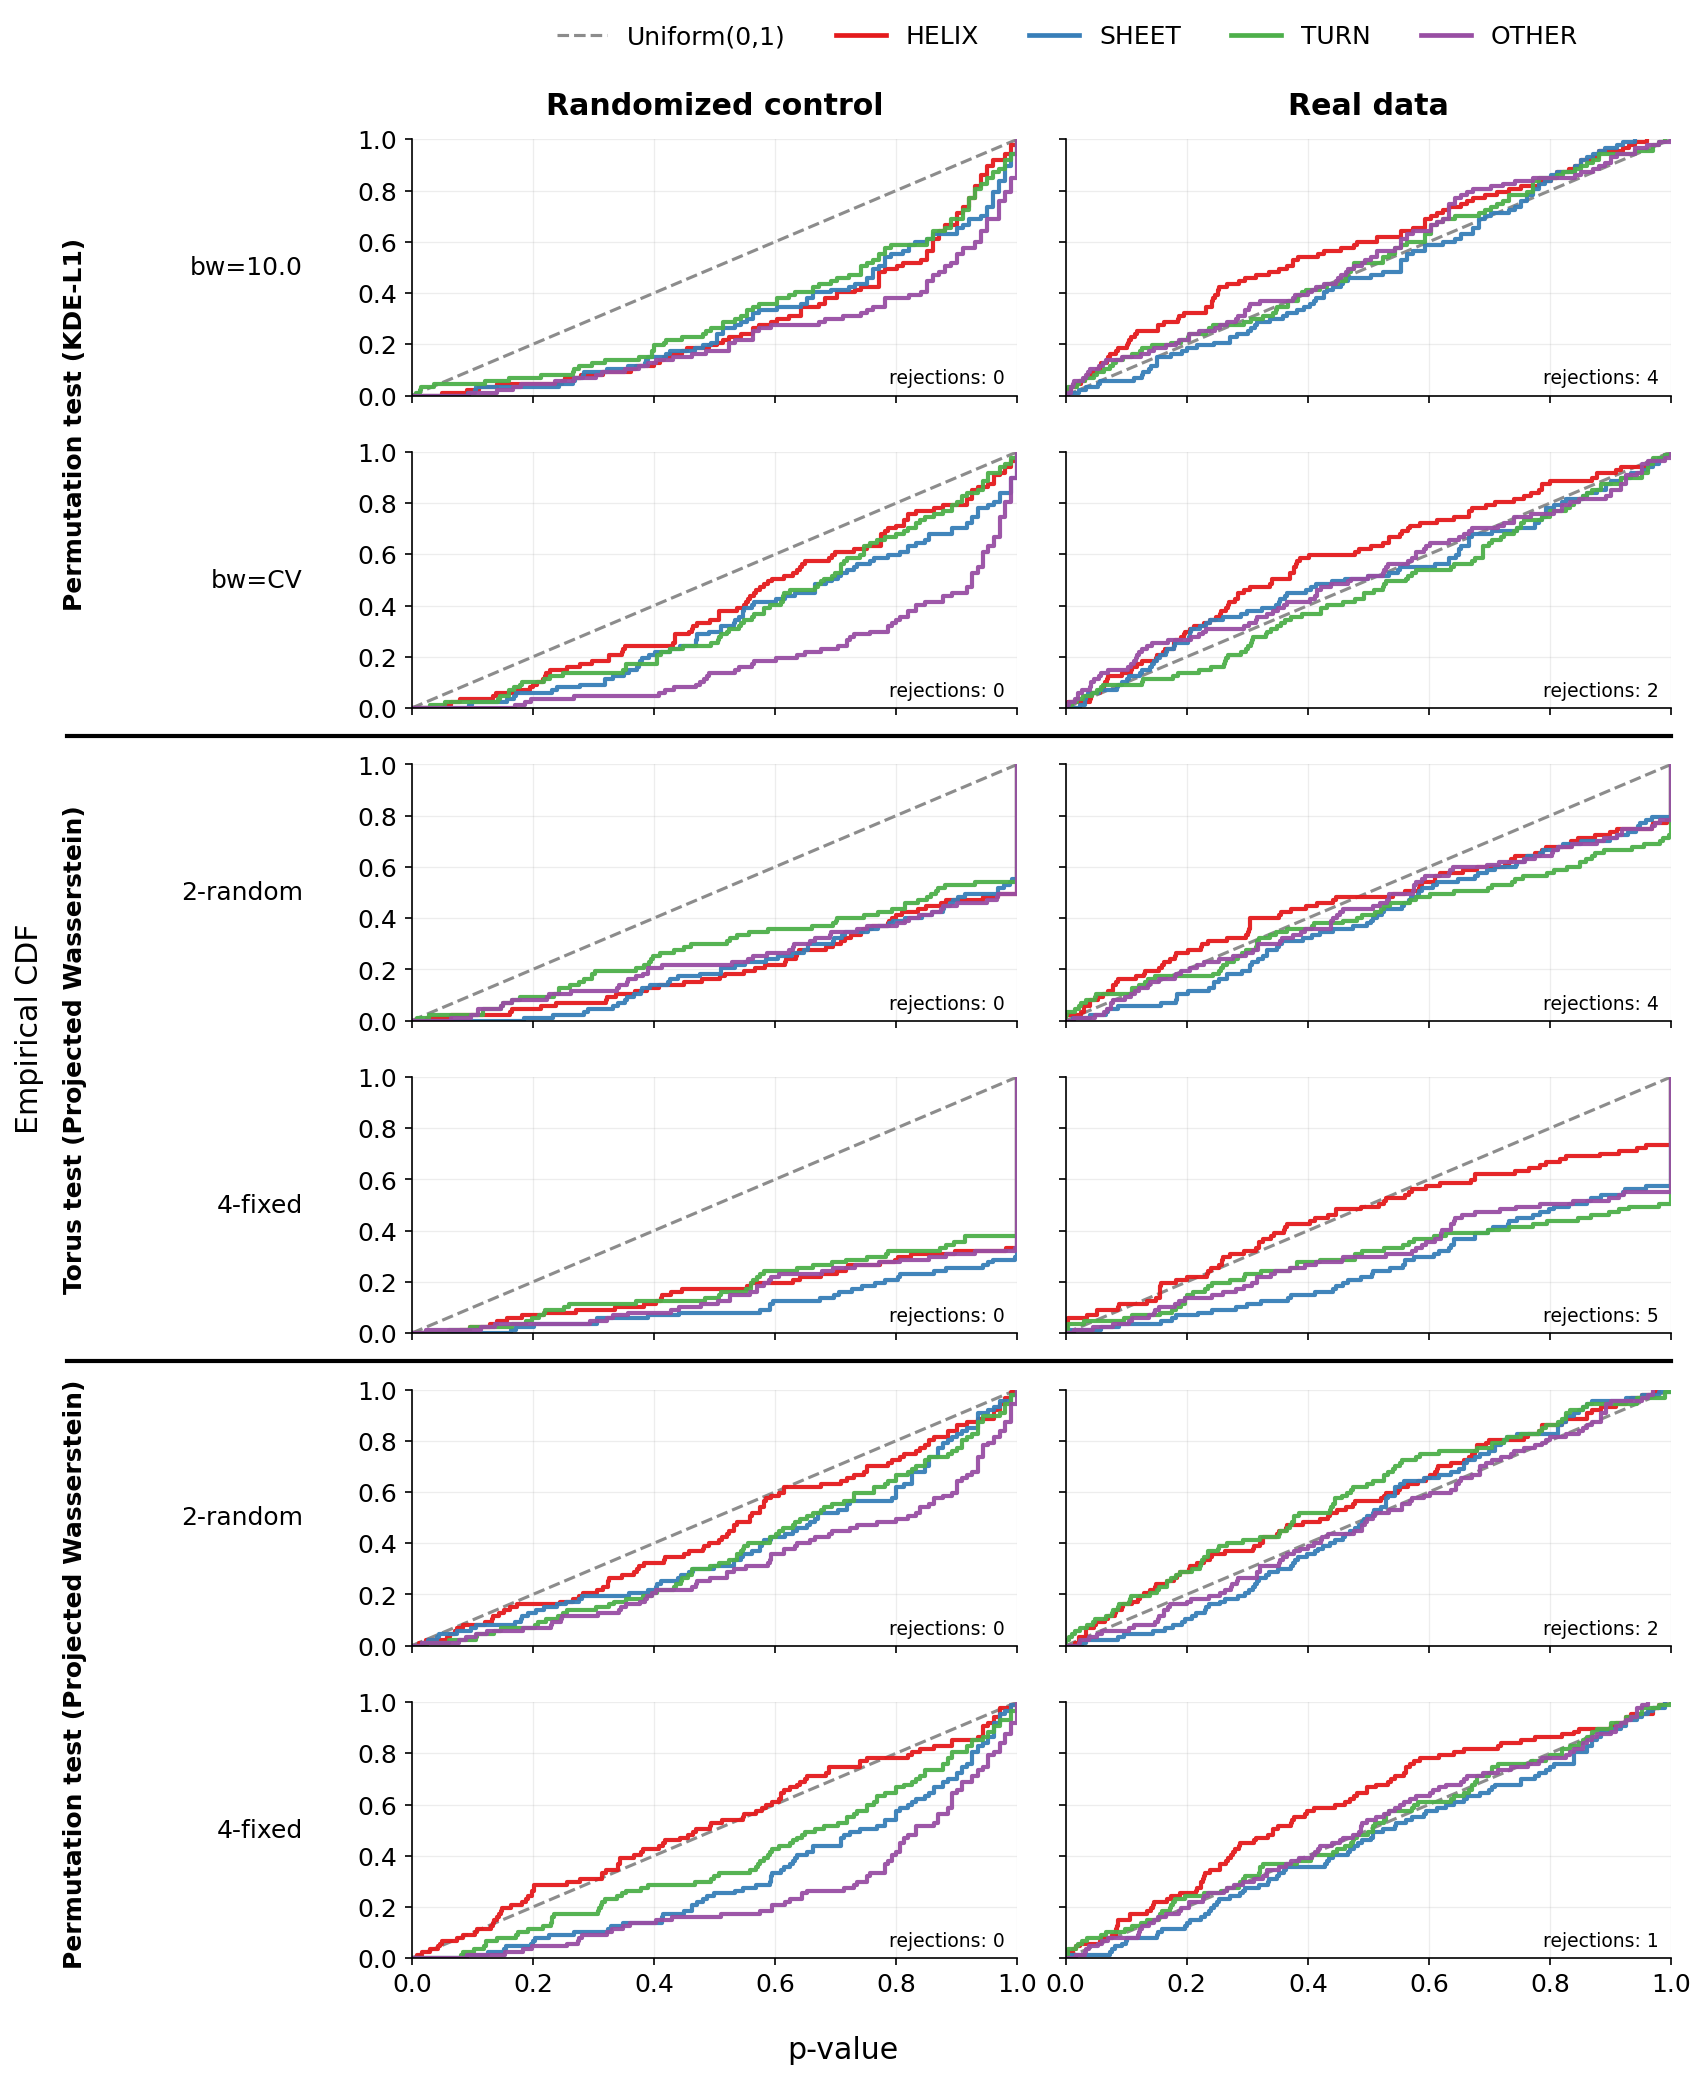

In [17]:
plt.close("all")
with mpl.style.context(PP5_MPL_STYLE):
    nrows, ncols = len(stat_test_order), len(randomization_order)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(11.5, 2.35 * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    fig.subplots_adjust(
        left=0.25, right=0.98, bottom=0.06, top=0.92, hspace=0.22, wspace=0.08
    )

    # Column headers: randomization type label at the top of each column
    for col_idx, randomization_type in enumerate(randomization_order):
        axes[0, col_idx].set_title(
            randomization_display.get(randomization_type, randomization_type),
            fontweight="bold",
            pad=12,
        )

    # Row labels: stat-test / parameter string to the left of each row
    for row_idx, row in df_plot_rows.iterrows():
        row_label = row["test_params"] or row["stat_test"]
        axes[row_idx, 0].annotate(
            row_label,
            xy=(-0.18, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=12,
            annotation_clip=False,
        )

    # Legend handles: dashed line for the Uniform(0,1) reference + one line per SS class
    legend_handles = [
        Line2D([0], [0], color="0.55", ls="--", lw=1.5, label="Uniform(0,1)"),
        *[
            Line2D(
                [0],
                [0],
                color=ss_colors.get(ss, "#444444"),
                lw=2.25,
                label=ss_display.get(ss, ss.title()),
            )
            for ss in ss_order
        ],
    ]

    # Main panel loop: one panel per (stat_test, randomization_type) combination
    for row_idx, stat_test_name in enumerate(stat_test_order):
        for col_idx, randomization_type in enumerate(randomization_order):
            idx = (df_all_pvals["stat_test"] == stat_test_name) & (
                df_all_pvals["codon_randomization"] == randomization_type
            )
            df_panel = df_all_pvals[idx]
            assert len(df_panel)

            ax = axes[row_idx, col_idx]
            # Diagonal reference line y=x corresponding to Uniform(0,1) p-values
            ax.plot(
                [0.0, 1.0],
                [0.0, 1.0],
                ls="--",
                color="0.55",
                lw=1.5,
                zorder=1,
            )

            # Empirical CDF of p-values for each secondary-structure class
            for ss in ss_order:
                df_group = df_panel[df_panel["condition_group"] == ss]
                if df_group.empty:
                    continue

                pvals = np.sort(df_group["pval"].to_numpy())
                m = len(pvals)
                x = np.concatenate(([0.0], pvals))
                y = np.arange(0, m + 1) / m
                ax.step(
                    x,
                    y,
                    where="post",
                    color=ss_colors.get(ss, "#444444"),
                    lw=2.0,
                    alpha=0.95,
                    zorder=2,
                )

            # Annotation in the bottom-right corner with the rejection count for this panel
            n_rejected = int(panel_rejections.loc[(stat_test_name, randomization_type)])
            ax.text(
                0.98,
                0.03,
                f"rejections: {n_rejected}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=9,
                # bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
            )
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.0)
            ax.set_xticks(np.linspace(0.0, 1.0, 6))
            ax.set_yticks(np.linspace(0.0, 1.0, 6))
            ax.grid(alpha=0.22, linewidth=0.6)
            ax.spines[["top", "right"]].set_visible(False)

    # Rotated family-name label centered vertically over its group of rows
    for _, group in df_plot_rows.groupby("test_family", sort=False):
        rows = group.index.to_list()
        top = axes[rows[0], 0].get_position().y1
        bottom = axes[rows[-1], 0].get_position().y0
        y_center = 0.5 * (top + bottom)
        fig.text(
            0.055,
            y_center,
            group.iloc[0]["test_family"],
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            fontweight="bold",
        )

    # Horizontal divider line between consecutive test-family groups
    for upper_rows, lower_rows in zip(family_row_groups, family_row_groups[1:]):
        upper_row = axes[upper_rows[-1], 0].get_position()
        lower_row = axes[lower_rows[0], 0].get_position()
        y = 0.5 * (upper_row.y0 + lower_row.y1)
        fig.add_artist(
            Line2D(
                [0.05, 0.98],
                [y, y],
                transform=fig.transFigure,
                color="black",
                lw=2.0,
            )
        )

    # Shared legend placed above the plot area
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.63, 0.985),
        ncol=len(legend_handles),
        frameon=False,
    )
    fig.supxlabel("p-value")
    fig.supylabel("Empirical CDF")

plt.show()

In [18]:
fig.savefig(OUT_DIR / "pvals-cdf.pdf", bbox_inches="tight")

## Repeat BH-q test but only within the same AA

In [19]:
aa1_col, aa2_col = [df_all_pvals[f"subgroup{j}"].str.get(0) for j in ("1", "2")]

# Sanity: all tests are comparing codons from the same AA
assert np.all(aa1_col == aa2_col)

In [20]:
print(f"{len(aa1_col.unique())=}")
print(sorted(aa1_col.unique()))

len(aa1_col.unique())=18
['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'Y']


In [21]:
rejections_aa_df_entries = []

for (ss, aa, stat_test_name, randomization_type), df_group in df_all_pvals.groupby(
    by=["condition_group", aa1_col, "stat_test", "codon_randomization"]
):
    pvals = df_group["pval"].to_numpy()
    m = len(pvals)
    if m < 1:
        raise RuntimeError("Empty?")

    # Benjamini-Hochberg procedure if m > 1
    if m > 1:
        p_thresh = mht_bh(q=FDR, pvals=pvals)
    else:
        p_thresh = FDR  # regular pval significance check

    pv_lt_thresh = pvals <= p_thresh
    n_rejected = np.sum(pv_lt_thresh)

    df_group_rejected = df_group[pv_lt_thresh]
    assert len(df_group_rejected) == n_rejected
    rejected_pairs = [
        f"{c1}:{c2}"
        for c1, c2 in zip(
            df_group_rejected["subgroup1"], df_group_rejected["subgroup2"]
        )
    ]
    rejected_pairs_str = str.join("; ", rejected_pairs)

    rejections_aa_df_entries.append(
        {
            "stat_test": stat_test_name,
            "codon_randomization": randomization_type,
            "SS": ss,
            "AA": aa,
            "n_hypotheses": m,
            "FDR": FDR,
            "bh_pvalue_threshold": p_thresh,
            "n_rejected": n_rejected,
            "rejected_pairs": rejected_pairs_str,
        }
    )

    # print(
    #     f"{ss=}, {aa=}, {stat_test_name=}, {randomization_type=}, {m=}, {n_rejected=}"
    # )

In [22]:
df_rejections_aa = pd.DataFrame(rejections_aa_df_entries)
df_rejections_aa = df_rejections_aa.sort_values(
    by=["stat_test", "codon_randomization", "SS", "AA", "n_hypotheses"]
)

df_rejections_aa.to_csv(OUT_DIR / "rejections_aa.csv", index=False)
df_rejections_aa

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),aa_ss,HELIX,A,6,0.05,0.00,0,
12,kde-l1(bw=10.0),aa_ss,HELIX,C,1,0.05,0.05,0,
24,kde-l1(bw=10.0),aa_ss,HELIX,D,1,0.05,0.05,0,
36,kde-l1(bw=10.0),aa_ss,HELIX,E,1,0.05,0.05,0,
48,kde-l1(bw=10.0),aa_ss,HELIX,F,1,0.05,0.05,0,
...,...,...,...,...,...,...,...,...,...
815,w2torus-perm(4-fixed),none,TURN,R,15,0.05,0.00,0,
827,w2torus-perm(4-fixed),none,TURN,S,15,0.05,0.00,0,
839,w2torus-perm(4-fixed),none,TURN,T,6,0.05,0.00,0,
851,w2torus-perm(4-fixed),none,TURN,V,6,0.05,0.00,0,


### Check for any rejections in the control data

In [23]:
idx_rejected_null = (df_rejections_aa["codon_randomization"] == "aa_ss") & (
    df_rejections_aa["n_rejected"] > 0
)
df_rejections_aa[idx_rejected_null]

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
832,w2torus(2-random),aa_ss,TURN,T,6,0.05,0.008333,1,T-ACA:T-ACT
680,w2torus-perm(2-random),aa_ss,TURN,D,1,0.05,0.050000,1,D-GAC:D-GAT
202,w2torus-perm(4-fixed),aa_ss,HELIX,V,6,0.05,0.008333,1,V-GTA:V-GTC


### Check for any rejections in the real data

In [24]:
idx_rejected_real = (df_rejections_aa["codon_randomization"] == "none") & (
    df_rejections_aa["n_rejected"] > 0
)
df_rejections_aa[idx_rejected_real]

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
109,kde-l1(bw=10.0),none,HELIX,L,15,0.05,0.006667,2,L-CTC:L-TTG; L-CTC:L-CTG
373,kde-l1(bw=10.0),none,OTHER,R,15,0.05,0.003333,1,R-AGA:R-CGC
613,kde-l1(bw=10.0),none,SHEET,T,6,0.05,0.008333,1,T-ACC:T-ACG
649,kde-l1(bw=10.0),none,TURN,A,6,0.05,0.008333,1,A-GCG:A-GCT
781,kde-l1(bw=10.0),none,TURN,P,6,0.05,0.025000,3,P-CCC:P-CCG; P-CCG:P-CCT; P-CCA:P-CCG
111,kde-l1(bw=CV),none,HELIX,L,15,0.05,0.003333,1,L-CTC:L-TTG
243,kde-l1(bw=CV),none,OTHER,D,1,0.05,0.050000,1,D-GAC:D-GAT
351,kde-l1(bw=CV),none,OTHER,P,6,0.05,0.008333,1,P-CCC:P-CCG
375,kde-l1(bw=CV),none,OTHER,R,15,0.05,0.003333,1,R-AGA:R-CGC
579,kde-l1(bw=CV),none,SHEET,Q,1,0.05,0.050000,1,Q-CAA:Q-CAG


In [25]:
# Sanity: Total number of hypotheses per SS should be 87
_df_rejections_aa_groups = df_rejections_aa.groupby(
    by=["stat_test", "codon_randomization", "SS"]
)
# _df_rejections_aa_groups["n_hypotheses"].agg("sum")
_df_total_hypotheses_per_aa = _df_rejections_aa_groups.aggregate(
    total_hypotheses=pd.NamedAgg(column="n_hypotheses", aggfunc="sum")
).reset_index()

assert np.all(_df_total_hypotheses_per_aa["total_hypotheses"] == 87), (
    "Total hypotheses per SS should be 87"
)
_df_total_hypotheses_per_aa.head()

,stat_test,codon_randomization,SS,total_hypotheses
0,kde-l1(bw=10.0),aa_ss,HELIX,87
1,kde-l1(bw=10.0),aa_ss,OTHER,87
2,kde-l1(bw=10.0),aa_ss,SHEET,87
3,kde-l1(bw=10.0),aa_ss,TURN,87
4,kde-l1(bw=10.0),none,HELIX,87


### Plot num rejections per AA for each test type

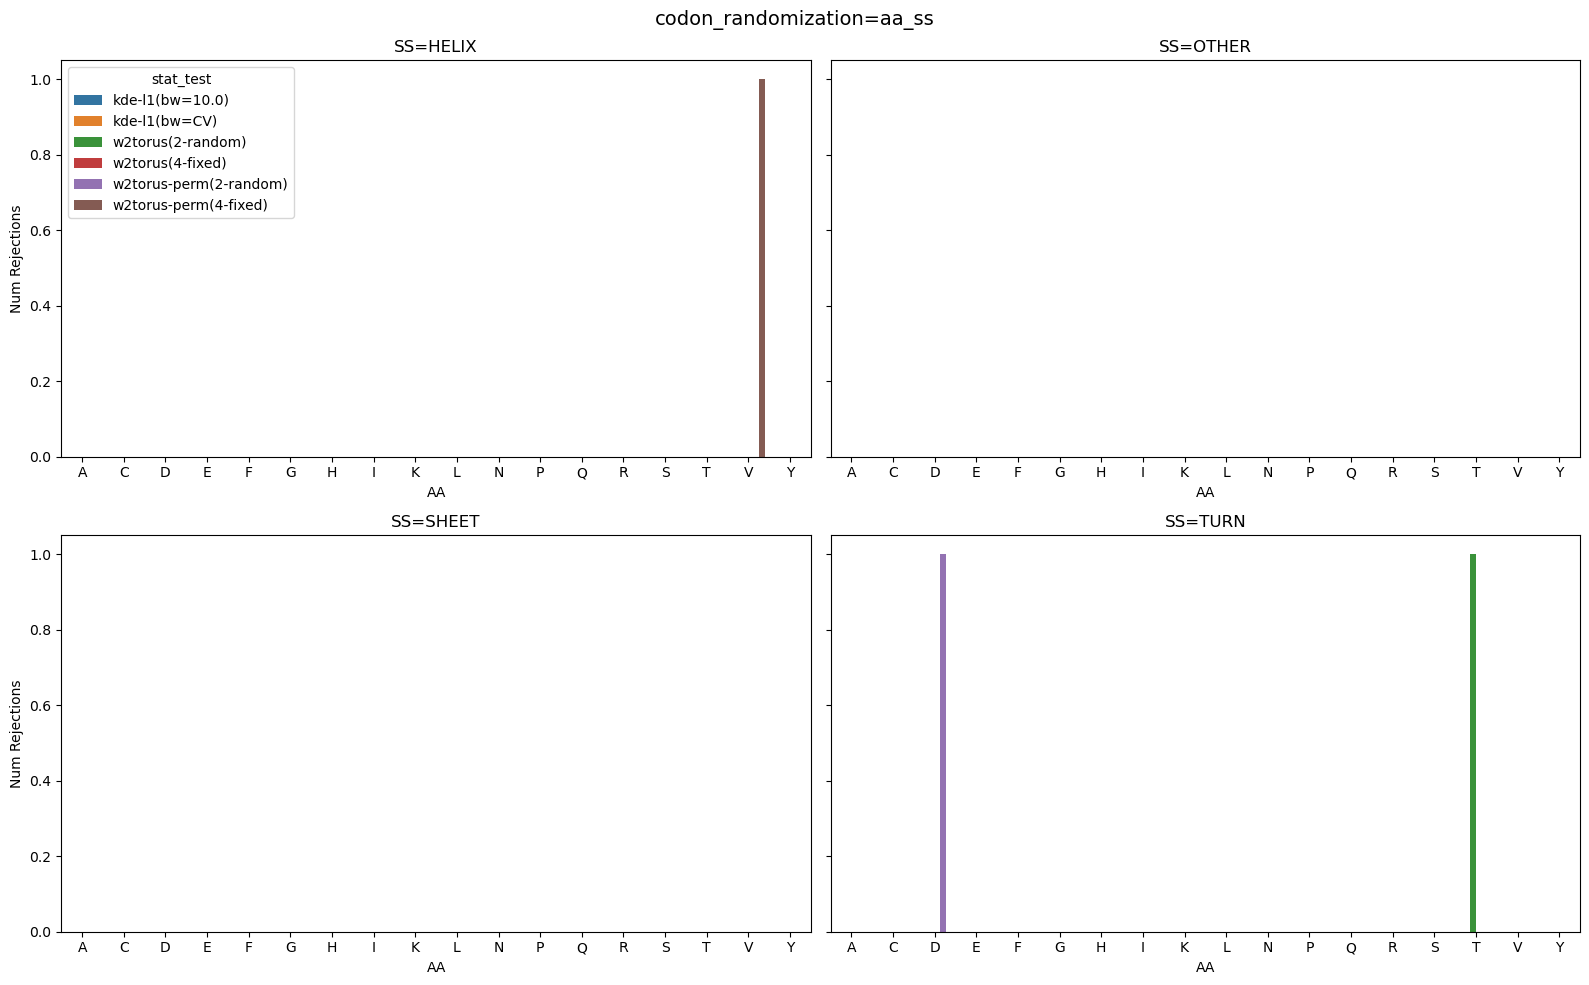

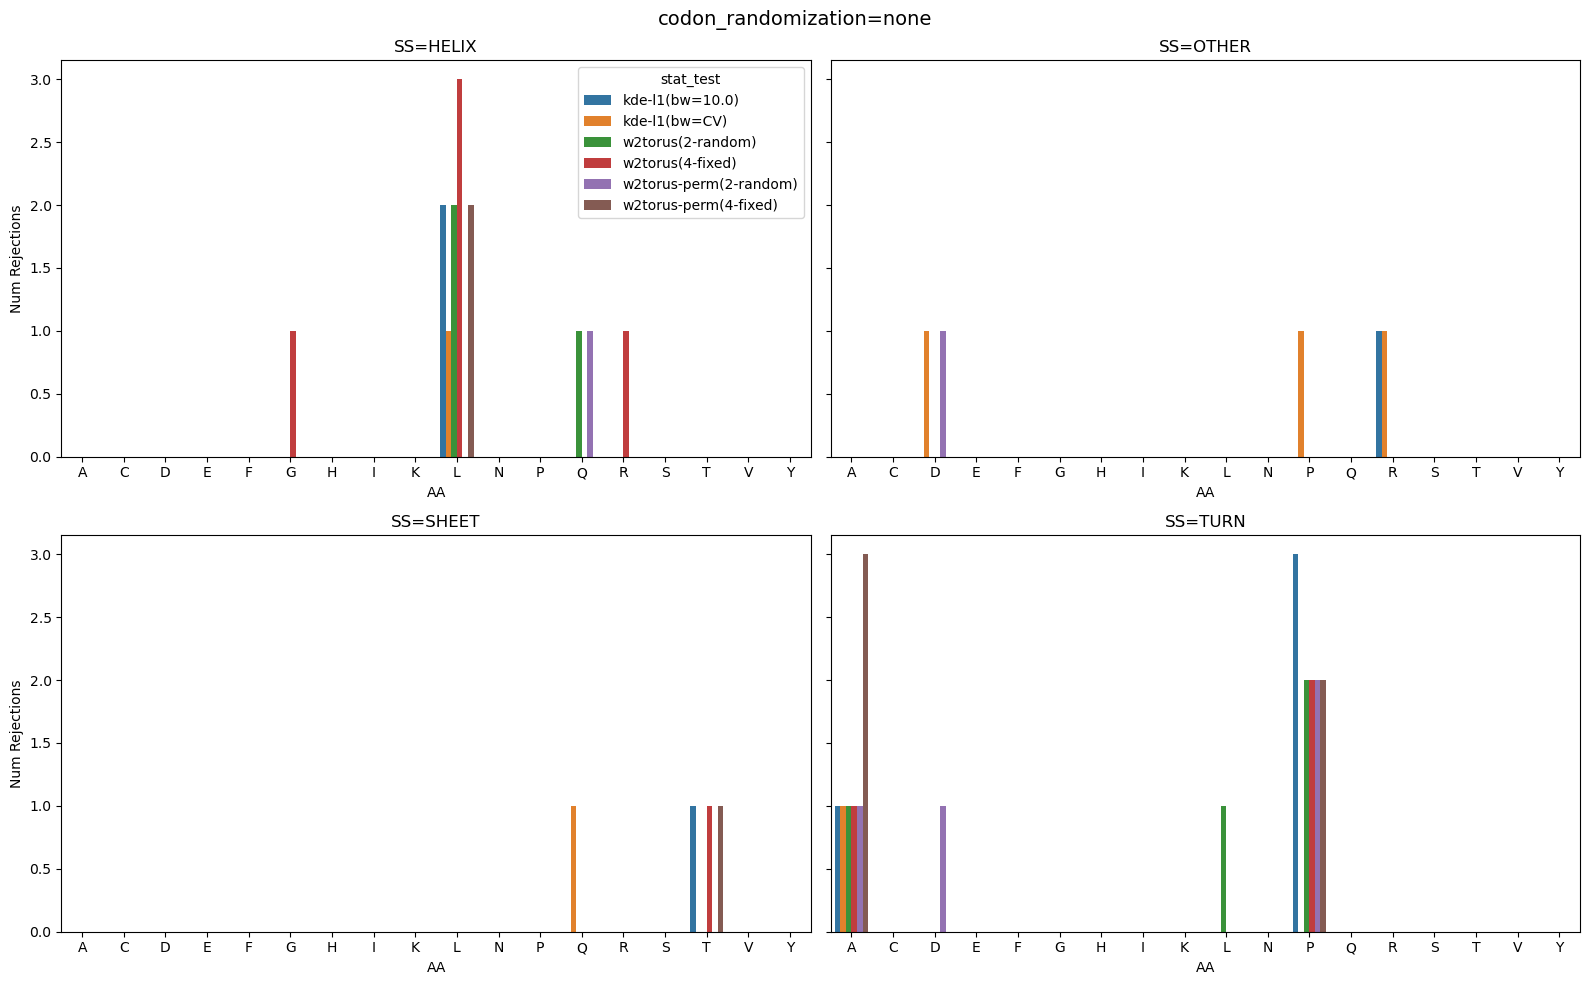

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_rejections_aa.copy()

ALL_AAS = sorted(df["AA"].dropna().unique().tolist())
ALL_SS = sorted(df["SS"].dropna().unique().tolist())
ALL_RAND_TYPES = sorted(df["codon_randomization"].unique().tolist())

assert len(ALL_SS) == 4
assert len(ALL_AAS) == 18  # M and W only have a single codon

# One figure per codon_randomization value, split into four subplots for the AAs
for randomization_type in ALL_RAND_TYPES:
    d = df[df["codon_randomization"] == randomization_type].copy()
    stat_tests = sorted(d["stat_test"].dropna().unique().tolist())

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()
    for i, ss in enumerate(ALL_SS):
        ax = axes[i]
        sub = d[d["SS"] == ss]
        sns.barplot(
            data=sub,
            x="AA",
            y="n_rejected",
            hue="stat_test",
            order=ALL_AAS,
            hue_order=stat_tests,
            errorbar=None,
            ax=ax,
        )
        ax.set_title(f"SS={ss}")
        ax.set_xlabel("AA")
        ax.set_ylabel("Num Rejections")
        ax.tick_params(axis="x", rotation=0)
        # legend only on the first subplot
        if i != 0:
            ax.get_legend().remove()
    fig.suptitle(f"codon_randomization={randomization_type}", fontsize=14)
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"rejections_aa-codon_randomization={randomization_type}.pdf")
    plt.show()
    plt.close(fig)